<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Logistic%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression from Scratch

## Introduction

**Logistic regression** is the canonical algorithm for binary classification. Despite its name, it is a *classification* model, not a regression model.

### Why Not Linear Regression for Classification?

If we try to use linear regression for binary classification ($y \in \{0,1\}$), we get:
- Predictions outside $[0,1]$, which cannot be interpreted as probabilities
- The MSE loss is not well-suited for classification (non-convex when composed with step function)

### Probabilistic Model

Logistic regression models the *posterior probability* of class 1:

$$P(y=1 \mid \mathbf{x}; \boldsymbol{\theta}) = \sigma(\boldsymbol{\theta}^\top\mathbf{x}), \quad \text{where} \quad \sigma(z) = \frac{1}{1+e^{-z}}$$

The **log-odds** (logit) is linear in $\mathbf{x}$:

$$\log \frac{P(y=1\mid\mathbf{x})}{P(y=0\mid\mathbf{x})} = \boldsymbol{\theta}^\top\mathbf{x}$$

This is why logistic regression is called a **generalized linear model (GLM)**.

### Learning Objectives
- Implement the sigmoid activation and binary cross-entropy loss
- Derive the gradient of the loss and implement batch gradient descent
- Evaluate a binary classifier with accuracy, confusion matrix, and ROC/AUC
- Compare our implementation to scikit-learn

<div align='center'>

![Logistic Regression](https://upload.wikimedia.org/wikipedia/commons/6/6d/Exam_pass_logistic_curve.jpeg)

*Logistic regression fits an S-shaped sigmoid curve to binary outcome data. Unlike linear regression, predictions are always in $[0,1]$ and interpretable as probabilities.*

</div>

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n$ | Number of features (before bias augmentation) |
| $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ | Design matrix (augmented with bias) |
| $\mathbf{x}^{(i)} \in \mathbb{R}^{n+1}$ | $i$-th training example (augmented) |
| $y^{(i)} \in \{0,1\}$ | True class label |
| $\boldsymbol{\theta} \in \mathbb{R}^{n+1}$ | Parameter vector (including bias $\theta_0$) |
| $z^{(i)} = \boldsymbol{\theta}^\top\mathbf{x}^{(i)}$ | Linear activation (logit) |
| $a^{(i)} = \sigma(z^{(i)})$ | Predicted probability of class 1 |
| $\hat{y}^{(i)} = \mathbf{1}[a^{(i)} > 0.5]$ | Predicted class label |
| $\mathcal{J}(\boldsymbol{\theta})$ | Binary cross-entropy cost |
| $\alpha$ | Learning rate |

In [1]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

#### Import the data

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, centers=2,
                  random_state=10, cluster_std=3)

In [3]:
m, n = X.shape

print(f"Num features is {n}")
print(f"Num samples is {m}")

Num features is 2
Num samples is 200


In [4]:
print(f"y shape: {y.shape}  — classes: {list(set(y.flatten()))}")

y shape: (200,)  — classes: [np.int64(0), np.int64(1)]


In [5]:
y = y[:,None]

Let's plot the data.

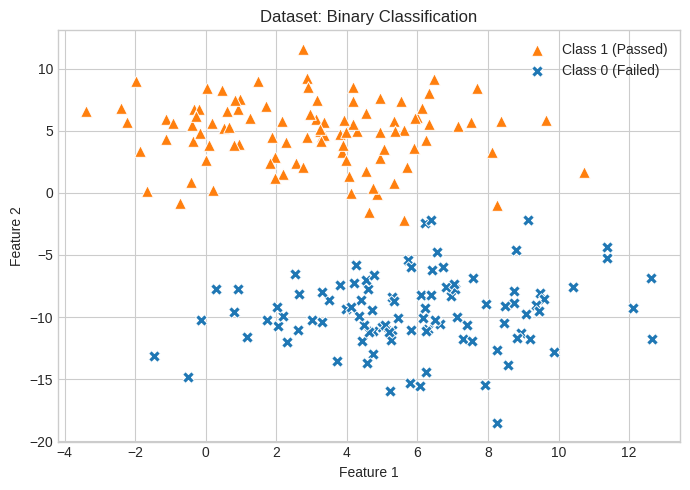

In [6]:
passed = (y == 1).reshape(-1, 1)
failed = (y == 0).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=X[passed[:, 0], 0], y=X[passed[:, 0], 1],
                marker="^", color="tab:orange", s=70, label="Class 1 (Passed)", ax=ax)
sns.scatterplot(x=X[failed[:, 0], 0], y=X[failed[:, 0], 1],
                marker="X", color="tab:blue", s=70, label="Class 0 (Failed)", ax=ax)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Dataset: Binary Classification")
ax.legend()
plt.tight_layout()
plt.show()

## Feature Scaling / Standardisation

Before running gradient descent, we **standardise** the features:

$$\tilde{x}_j = \frac{x_j - \mu_j}{\sigma_j}$$

**Why is this important?**
- Without scaling, features with large magnitudes dominate the gradient → the cost function is elongated and gradient descent zigzags
- After standardisation, the contours of $\mathcal{J}$ are more circular → faster and more stable convergence
- The bias term $x_0 = 1$ is **not** standardised

> **Important for deployment:** store $\mu$ and $\sigma$ from the training set. At test time, apply the *same* transformation — do not re-compute statistics from the test data.

In [7]:
def standarizeX(X, fakeIt = False):
  """
  Standarizes the features of X to have 0 mean and unit variance.

  Arguments:
  X -- feature matrix X (m, n+1)

  Returns:
  X -- standarized matix X
  mu, sigma -- mean and variance of the features (for new samples)
  """

  mu = np.mean(X, axis = 0)
  sigma = np.std(X, axis = 0)

  # standarize X.
  """
  Insert your code here.
  """
  X = (X - mu) / sigma

  return X, mu, sigma

In [8]:
X, mu, sigma = standarizeX(X)

In [9]:
print("-" * 45)
print("  Feature Standardisation")
print("-" * 45)
print(f"  Mean  : {mu.round(4)}")
print(f"  Std   : {sigma.round(4)}")
print("-" * 45)

---------------------------------------------
  Feature Standardisation
---------------------------------------------
  Mean  : [ 4.4399 -2.4303]
  Std   : [3.217  7.7223]
---------------------------------------------


In [10]:
print("First 5 rows of X:")
print(X[:5])

First 5 rows of X:
[[ 0.39633173  0.58218062]
 [-0.55400309 -0.74400439]
 [-1.223129    0.99177549]
 [-1.01838314 -1.19025708]
 [ 0.34385432  1.27578997]]


Before continuing, we will add the first column of all 1's ($x_0$ for the intercept term).

In [11]:
X = np.concatenate([np.ones((m,1)), X], axis = 1)

In [12]:
print("First 5 rows of X:")
print(X[:5])

First 5 rows of X:
[[ 1.          0.39633173  0.58218062]
 [ 1.         -0.55400309 -0.74400439]
 [ 1.         -1.223129    0.99177549]
 [ 1.         -1.01838314 -1.19025708]
 [ 1.          0.34385432  1.27578997]]


## Helper functions

Now we will define a few helper function that we will put together to build the logistic regression model.

### Sigmoid (Logistic) Function

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

**Key properties:**
- Range: $\sigma(z) \in (0, 1)$ for all $z \in (-\infty, +\infty)$ → interpretable as probability
- Symmetry: $\sigma(-z) = 1 - \sigma(z)$
- Decision boundary: $\sigma(0) = 0.5$, so we predict class 1 if $\boldsymbol{\theta}^\top\mathbf{x} > 0$
- **Derivative (used in backpropagation):** $\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$

Proof of derivative:
$$\frac{d}{dz}\sigma(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z)(1-\sigma(z))$$

In [13]:
def sigmoid(z):
    """
    Implement the sigmoid function

    Arguments:
    y -- a scalar (float) - or numpy array.

    Return:
    A -- the sigmoid function evaluated on z  - or (squeezed) numpy array.
    """

    # Sigmoid function.
    """
    Insert your code here.
    """
    A = 1 / (1 + np.exp(-z))

    return A

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_444/977865070.py:7: SyntaxWarning: invalid escape sequence '\s'
  ax.axhline(0.5, color='crimson', linestyle='--', linewidth=1.2, label='$\sigma(0) = 0.5$')
/tmp/ipykernel_444/977865070.py:12: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sigma(z)$')


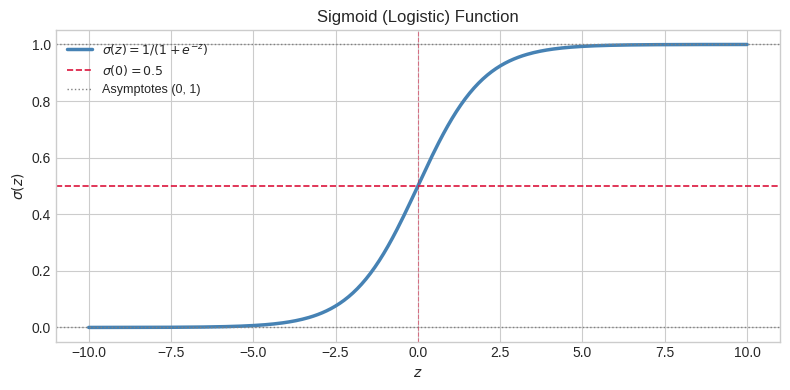

In [14]:
xs_sigmoid = np.linspace(-10, 10, 300)
ys_sigmoid = sigmoid(xs_sigmoid)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs_sigmoid, ys_sigmoid, color='steelblue', linewidth=2.5,
        label=r'$\sigma(z) = 1 / (1 + e^{-z})$')
ax.axhline(0.5, color='crimson', linestyle='--', linewidth=1.2, label='$\sigma(0) = 0.5$')
ax.axhline(1.0, color='gray',    linestyle=':',  linewidth=1.0, label='Asymptotes (0, 1)')
ax.axhline(0.0, color='gray',    linestyle=':',  linewidth=1.0)
ax.axvline(0.0, color='crimson', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('$z$')
ax.set_ylabel('$\sigma(z)$')
ax.set_title('Sigmoid (Logistic) Function')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

You should verify that the output is bounded between 0 and 1, and equals exactly 0.5 at $z=0$. Let's check a few key values:

In [15]:
print("Sigmoid sanity checks:")
print(f"  sigma(0)   = {sigmoid(0):.4f}   (expected 0.5000)")
print(f"  sigma(10)  = {sigmoid(10):.6f} (expected ≈ 1.0000)")
print(f"  sigma(-10) = {sigmoid(-10):.6f} (expected ≈ 0.0000)")
print(f"  sigma(-z) = 1 - sigma(z): sigma(-2) = {sigmoid(-2):.4f}, 1-sigma(2) = {1-sigmoid(2):.4f}")

Sigmoid sanity checks:
  sigma(0)   = 0.5000   (expected 0.5000)
  sigma(10)  = 0.999955 (expected ≈ 1.0000)
  sigma(-10) = 0.000045 (expected ≈ 0.0000)
  sigma(-z) = 1 - sigma(z): sigma(-2) = 0.1192, 1-sigma(2) = 0.1192


In [16]:
def initialize(n):
    """
    Initialise the thetas to tensors of dimensions (n+1,1)

    Arguments:
    n -- a scalar (int)

    Return:
    theta -- a matrix of dimensions (n+1,1) containing all zero
    """
    theta = np.zeros((n+1,1))

    return theta

In [17]:
theta = initialize(n)
print(f"Initialised theta — shape: {theta.shape}  (bias + {n} features, all zeros)")

Initialised theta — shape: (3, 1)  (bias + 2 features, all zeros)


## Cost Function: Binary Cross-Entropy

### Derivation from Maximum Likelihood

The probability of a single observation under our model:
$$P(y^{(i)} \mid \mathbf{x}^{(i)}; \boldsymbol{\theta}) = (a^{(i)})^{y^{(i)}}(1-a^{(i)})^{1-y^{(i)}}$$

The log-likelihood of the full dataset (assuming i.i.d. samples):
$$\ell(\boldsymbol{\theta}) = \sum_{i=1}^m \left[ y^{(i)}\log a^{(i)} + (1-y^{(i)})\log(1-a^{(i)}) \right]$$

Minimising the **negative** average log-likelihood gives the binary cross-entropy cost:

$$\mathcal{J}(\boldsymbol{\theta}) = -\frac{1}{m}\sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)}), \qquad \mathcal{L}(a, y) = -\left[y\log a + (1-y)\log(1-a)\right]$$

**Intuition:**
- If $y=1$: the loss is $-\log a^{(i)}$, which penalises low confidence ($a \approx 0$) heavily
- If $y=0$: the loss is $-\log(1-a^{(i)})$, which penalises high confidence ($a \approx 1$) heavily

**Convexity:** The binary cross-entropy $\mathcal{J}$ is **convex** in $\boldsymbol{\theta}$ (unlike neural network losses), so gradient descent converges to the global minimum.

In [18]:
def cost_function(X, y, theta):
    """
    cost_function(X, y, theta) computes the cost of using theta as the
    parameter for logistic regression to fit the data points in X and y.

    Arguments:
    theta -- weight vector, a numpy array of size (n+1, 1)
    X -- data of shape (m, n+1)
    Y -- true "label" vector (containing 0 for class 0, 1 for class 1), of shape (m,1)

    Output:
    J -- the cost function.
    """
    ## number of training examples
    m = len(y)

    ## Calculate the estimates A.
    A = sigmoid(np.matmul(X, theta))

    ## Calculate the cost with the given estimates. (should be vectorized) - Add epsilon for numerical estability.
    epsilon = 1e-7
    J_per_sample = -(y*np.log(A+epsilon) + (1-y)*np.log(1-A+epsilon))
    J = np.sum(J_per_sample) / m

    return J

In [19]:
cost = cost_function(X, y, theta)
print(f"Initial cost (zero weights ≈ random classifier): {cost:.4f}  (expected ≈ ln 2 ≈ 0.6931)")

Initial cost (zero weights ≈ random classifier): 0.6931  (expected ≈ ln 2 ≈ 0.6931)


## Gradient of the Cost Function

### Derivation

Starting from $\mathcal{J}(\boldsymbol{\theta}) = -\frac{1}{m}\sum_i [y^{(i)}\log a^{(i)} + (1-y^{(i)})\log(1-a^{(i)})]$ with $a^{(i)} = \sigma(\boldsymbol{\theta}^\top\mathbf{x}^{(i)})$:

**Step 1** — Derivative of loss w.r.t. $a^{(i)}$:
$$\frac{\partial \mathcal{L}}{\partial a^{(i)}} = -\frac{y^{(i)}}{a^{(i)}} + \frac{1-y^{(i)}}{1-a^{(i)}}$$

**Step 2** — Derivative of sigmoid w.r.t. $z^{(i)} = \boldsymbol{\theta}^\top\mathbf{x}^{(i)}$:
$$\frac{\partial a^{(i)}}{\partial z^{(i)}} = a^{(i)}(1-a^{(i)})$$

**Step 3** — Chain rule and simplification:
$$\frac{\partial \mathcal{L}}{\partial z^{(i)}} = \frac{\partial \mathcal{L}}{\partial a^{(i)}} \cdot \frac{\partial a^{(i)}}{\partial z^{(i)}} = \left(-\frac{y^{(i)}}{a^{(i)}} + \frac{1-y^{(i)}}{1-a^{(i)}}\right) a^{(i)}(1-a^{(i)}) = a^{(i)} - y^{(i)}$$

**Step 4** — Gradient w.r.t. $\theta_j$:
$$\frac{\partial \mathcal{J}}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m (a^{(i)} - y^{(i)}) x_j^{(i)}$$

**Vectorised form** (all $j$ simultaneously):
$$\boxed{\nabla_{\boldsymbol{\theta}}\mathcal{J}(\boldsymbol{\theta}) = \frac{1}{m}\mathbf{X}^\top(\mathbf{a} - \mathbf{y})}$$

This has the same elegant form as linear regression's gradient! The difference is that $\mathbf{a} = \sigma(\mathbf{X}\boldsymbol{\theta})$ instead of $\mathbf{X}\boldsymbol{\theta}$.

In [20]:
def calculate_gradient(X, y, theta):
    """
    calculate_gradient(X, y, theta) computes the gradient of the cost function for
    the current thetas given X and y.

    Arguments:
    theta -- weight vector, a numpy array of size (n+1, 1)
    X -- data of shape (m, n+1)
    Y -- true "label" vector (containing 0 for class 0, 1 for class 1), of shape (m,1)

    output:
    dJ -- Grandiet of the cost function with respect to the thetas (n+1,1)
    """
    ## number of training examples
    m = len(y)

    ## Calculate the estimates A.
    A = sigmoid(np.matmul(X, theta))

    ## Calculate the cost with the given estimates (should be vectorized)
    """
    Insert your code here.
    """
    dJ = 1/m * X.T.dot(A-y)

    return dJ

In [21]:
dJ = calculate_gradient(X, y, theta)
print(f"Gradient shape : {dJ.shape}")
for j, g in enumerate(dJ.flatten()):
    print(f"  dJ/dtheta_{j} = {g:.6f}")

Gradient shape : (3, 1)
  dJ/dtheta_0 = 0.000000
  dJ/dtheta_1 = 0.225427
  dJ/dtheta_2 = -0.465798


## Gradient descent.
With these functions we perform the gradient descent algorithm.

$$\displaystyle
\theta := \theta -\alpha \cdot \nabla_\theta(J(\theta))
$$


In [22]:
def optimize(theta, X, y, num_iterations, learning_rate, print_cost = True):
    """
    This function optimizes w and b by running a gradient descent algorithm

    Arguments:
    theta -- weight vector, a numpy array of size (n+1, 1)
    X -- data of shape (m, n+1)
    Y -- true "label" vector (containing 0 for class 0, 1 for class 1), of shape (m,1)
    num_iterations -- number of iterations of the optimization loop
    learning_rate -- learning rate of the gradient descent update rule
    print_cost -- True to print the loss every 10 steps

    Returns:
    theta -- a vector containing the weights
    costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    """
    costs = []

    for i in range(num_iterations):

        cost = cost_function(X, y, theta)
        dJ = calculate_gradient(X, y, theta)

        theta = theta - learning_rate * dJ

        if i % 10 == 0:
            costs.append(cost)

        if print_cost and i % 200 == 0:
            print(f"  [{i:5d}/{num_iterations}]  Cost = {cost:.6f}")

    return theta, costs

Set the training parameters:

In [23]:
num_iterations = 5000
learning_rate = 0.005

In [24]:
optimized_theta, costs = optimize(theta, X, y, num_iterations, learning_rate)

  [    0/5000]  Cost = 0.693147
  [  200/5000]  Cost = 0.495614
  [  400/5000]  Cost = 0.385609
  [  600/5000]  Cost = 0.317536
  [  800/5000]  Cost = 0.271576
  [ 1000/5000]  Cost = 0.238487
  [ 1200/5000]  Cost = 0.213506
  [ 1400/5000]  Cost = 0.193955
  [ 1600/5000]  Cost = 0.178219
  [ 1800/5000]  Cost = 0.165266
  [ 2000/5000]  Cost = 0.154407
  [ 2200/5000]  Cost = 0.145165
  [ 2400/5000]  Cost = 0.137198
  [ 2600/5000]  Cost = 0.130252
  [ 2800/5000]  Cost = 0.124141
  [ 3000/5000]  Cost = 0.118719
  [ 3200/5000]  Cost = 0.113872
  [ 3400/5000]  Cost = 0.109513
  [ 3600/5000]  Cost = 0.105568
  [ 3800/5000]  Cost = 0.101981
  [ 4000/5000]  Cost = 0.098702
  [ 4200/5000]  Cost = 0.095694
  [ 4400/5000]  Cost = 0.092922
  [ 4600/5000]  Cost = 0.090360
  [ 4800/5000]  Cost = 0.087983


In [25]:
print("-" * 45)
print("  Gradient Descent — Optimised Weights")
print("-" * 45)
for j, t in enumerate(optimized_theta.flatten()):
    label = "bias" if j == 0 else f"feat. {j}"
    print(f"  theta_{j} ({label:7s}) : {t:.6f}")
print("-" * 45)

---------------------------------------------
  Gradient Descent — Optimised Weights
---------------------------------------------
  theta_0 (bias   ) : 0.027255
  theta_1 (feat. 1) : -0.693888
  theta_2 (feat. 2) : 2.960182
---------------------------------------------


## Cost function vs. number of iterations

Let's see how the cost function decrease with the number of iterations. We have the value of the cost function every $10$ iterations so we can easily plot it.

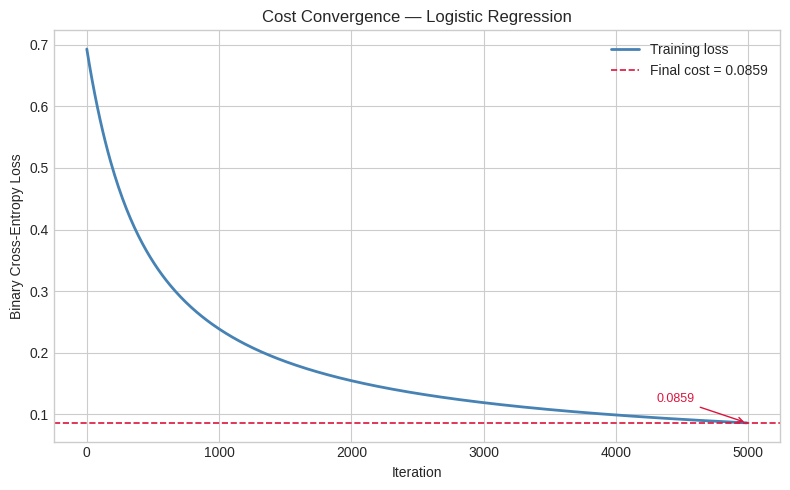

In [26]:
final_cost = costs[-1]
iters = list(range(0, len(costs) * 10, 10))

plt.figure(figsize=(8, 5))
plt.plot(iters, costs, color='steelblue', linewidth=2, label='Training loss')
plt.axhline(final_cost, color='crimson', linestyle='--', linewidth=1.2,
            label=f'Final cost = {final_cost:.4f}')
plt.annotate(f'{final_cost:.4f}',
             xy=(iters[-1], final_cost),
             xytext=(-65, 15), textcoords='offset points',
             color='crimson', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.0))
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Cost Convergence — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Prediction and Decision Threshold

Once trained, the model outputs $a = \sigma(\boldsymbol{\theta}^\top\mathbf{x}) \in (0,1)$ — the estimated probability that $y=1$.

We apply a **decision threshold** $\tau$ (default 0.5):
$$\hat{y} = \begin{cases} 1 & \text{if } a > \tau \\ 0 & \text{if } a \leq \tau \end{cases}$$

The **decision boundary** is the hyperplane $\{\mathbf{x} : \boldsymbol{\theta}^\top\mathbf{x} = 0\}$ — a linear boundary in the feature space (after standardisation). This is why logistic regression is a **linear classifier**.

> **Threshold choice:** $\tau = 0.5$ is optimal only when misclassification costs are equal. In practice, adjust $\tau$ depending on the relative cost of false positives vs. false negatives (e.g., medical diagnosis prefers low false negative rate).

In [27]:
def predict(theta, X):
    '''
    Predict whether the label is 0 or 1

    Arguments:
    theta -- weights, a numpy array of size (n+1, 1)
    X -- data of size (m, n+1)

    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1)
    '''

    m  = X.shape[0]
    Y_prediction = np.zeros((m,1))

    A = sigmoid(np.matmul(X, theta))

    Y_prediction[A>0.5] = 1

    assert (Y_prediction.shape == (m,1))

    return Y_prediction


In [28]:
pred = predict(optimized_theta, X)

And the score (accuracy) is:

In [29]:
acc = np.sum(pred == y) / m
print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

Accuracy: 0.9900  (99.00%)


### Decision Boundary (From-Scratch Model)

Since we have 2 features, we can visualise the linear decision boundary learned by our gradient descent model. The boundary is where $\boldsymbol{\theta}^\top\mathbf{x} = 0$, i.e., $\theta_0 + \theta_1\tilde{x}_1 + \theta_2\tilde{x}_2 = 0$, which gives:

$$\tilde{x}_2 = -\frac{\theta_1}{\theta_2}\tilde{x}_1 - \frac{\theta_0}{\theta_2}$$

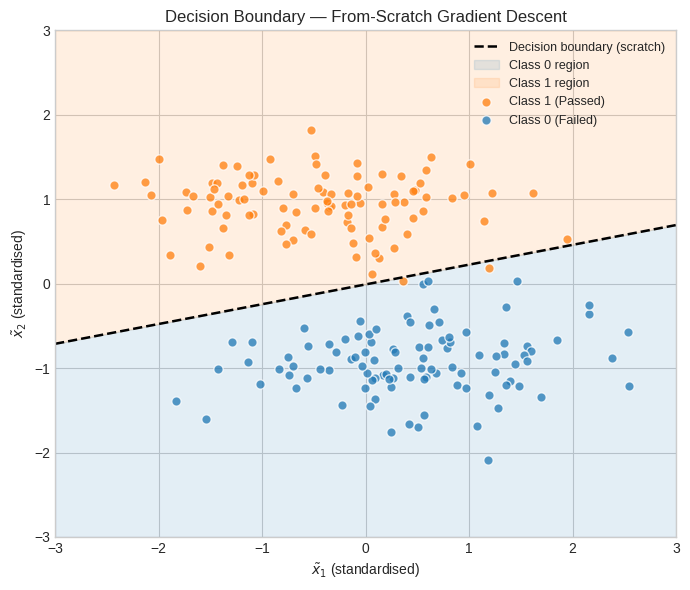

In [30]:
theta0, theta1, theta2 = optimized_theta.flatten()
slope_scratch = -theta1 / theta2
intercept_scratch = -theta0 / theta2

xmin, xmax, ymin, ymax = -3.0, 3.0, -3.0, 3.0
xd = np.array([xmin, xmax])
yd = slope_scratch * xd + intercept_scratch

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(xd, yd, 'k--', lw=1.8, label='Decision boundary (scratch)')
ax.fill_between(xd, yd, ymin, color='tab:blue',   alpha=0.12, label='Class 0 region')
ax.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.12, label='Class 1 region')
ax.scatter(X[passed[:, 0], 1], X[passed[:, 0], 2],
           s=45, alpha=0.75, color='tab:orange', edgecolors='white', label='Class 1 (Passed)')
ax.scatter(X[failed[:, 0], 1], X[failed[:, 0], 2],
           s=45, alpha=0.75, color='tab:blue',   edgecolors='white', label='Class 0 (Failed)')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r'$\tilde{x}_1$ (standardised)')
ax.set_ylabel(r'$\tilde{x}_2$ (standardised)')
ax.set_title('Decision Boundary — From-Scratch Gradient Descent')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Predicted Probability Surface

We can visualise the probability $P(y=1|\mathbf{x})$ over the feature space as a heatmap:

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_444/781048688.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('Predicted Probability Surface — $P(y=1 \mid \mathbf{x})$')


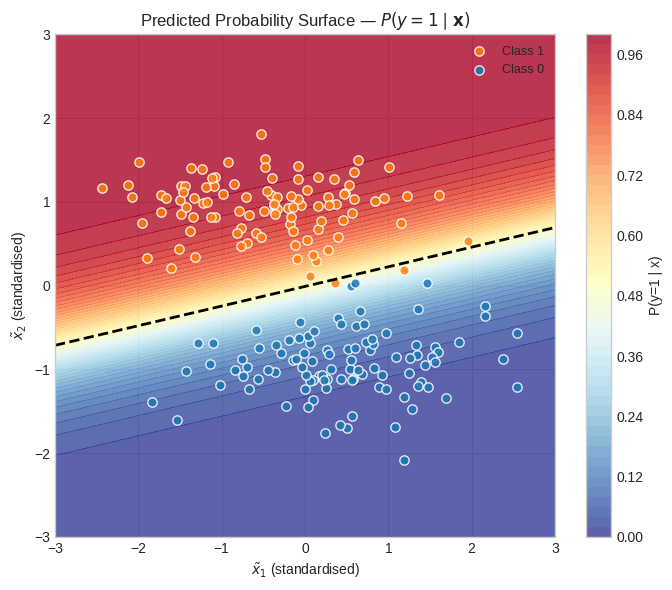

In [31]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[np.ones(xx.ravel().shape), xx.ravel(), yy.ravel()]
proba = sigmoid(grid @ optimized_theta).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(xx, yy, proba, levels=50, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(cf, ax=ax, label='P(y=1 | x)')
ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X[passed[:, 0], 1], X[passed[:, 0], 2],
           s=45, alpha=0.85, color='tab:orange', edgecolors='white', label='Class 1')
ax.scatter(X[failed[:, 0], 1], X[failed[:, 0], 2],
           s=45, alpha=0.85, color='tab:blue',   edgecolors='white', label='Class 0')
ax.set_xlabel(r'$\tilde{x}_1$ (standardised)')
ax.set_ylabel(r'$\tilde{x}_2$ (standardised)')
ax.set_title('Predicted Probability Surface — $P(y=1 \mid \mathbf{x})$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Evaluation Metrics

Accuracy alone is insufficient, especially for imbalanced datasets. We use:

**Confusion Matrix:**
$$\begin{array}{r|cc}
& {\text{Predicted}} \\
& \hat{y}=0 & \hat{y}=1 \\
\hline
\text{Actual} \quad y=0 & \text{TN} & \text{FP} \\
\quad y=1 & \text{FN} & \text{TP}
\end{array}$$

**Derived metrics:**
$$\text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}, \quad F_1 = \frac{2 \cdot \text{Prec} \cdot \text{Rec}}{\text{Prec} + \text{Rec}}$$

The **ROC curve** plots TPR (recall) vs. FPR = $\frac{FP}{FP+TN}$ across all thresholds $\tau$. The **AUC** (area under the ROC curve) equals the probability that the model ranks a random positive example higher than a random negative one.

=== Confusion Matrix ===
[[100   0]
 [  2  98]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       100
     Class 1       1.00      0.98      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



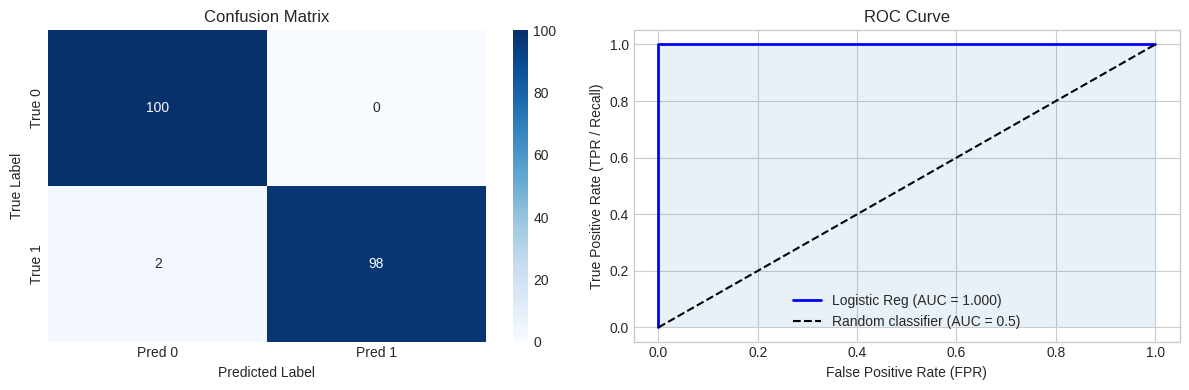


AUC = 1.0000  (1.0 = perfect, 0.5 = random)


In [32]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("=== Confusion Matrix ===")
print(confusion_matrix(y.flatten(), pred.flatten()))

print("\n=== Classification Report ===")
print(classification_report(y.flatten(), pred.flatten(), target_names=['Class 0', 'Class 1']))

# ROC Curve
A_proba = sigmoid(np.matmul(X, optimized_theta)).flatten()
fpr, tpr, thresholds = roc_curve(y.flatten(), A_proba)
auc = roc_auc_score(y.flatten(), A_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
import seaborn as sns
cm = confusion_matrix(y.flatten(), pred.flatten())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC curve
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Reg (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR / Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f"\nAUC = {auc:.4f}  (1.0 = perfect, 0.5 = random)")

## Bonus 1:
Logistic Regression with sklearn

As a side note, here is the code to see how easy it is in comparison to do the same with the sklearn library...

In [33]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

The LogisticRegression module from sklearn does already take into account the intercept term. You should remove it from your data.

In [34]:
logreg.fit(X[:,1:],y)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [35]:
logreg.coef_

array([[-0.70625688,  4.09439848]])

In [36]:
logreg.intercept_

array([0.08700737])

In [37]:
score = logreg.score(X[:, 1:], y)
print(f"sklearn training accuracy: {score:.4f}  ({score*100:.2f}%)")

sklearn training accuracy: 0.9950  (99.50%)


The score is calculated as the fraction of correctly classified samples: $\text{accuracy} = \frac{\text{number of correct predictions}}{m}$.

In [38]:
pred = logreg.predict(X[:,1:]).reshape(-1,1)

In [39]:
acc = np.sum(pred == y) / m
print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

Accuracy: 0.9950  (99.50%)


It is sometimes useful to be able to visualize the boundary line dividing the input space in which points are classified as belonging to the class of interest. Since we only have two features, this can be easily done in our case.

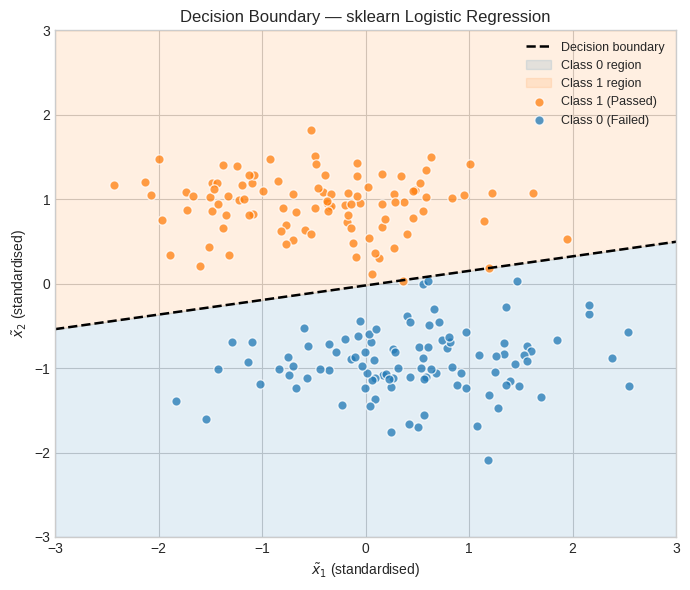

In [40]:
b_sk   = logreg.intercept_[0]
w1_sk, w2_sk = logreg.coef_.T
slope_sk = -w1_sk / w2_sk
c_sk     = -b_sk  / w2_sk

xmin, xmax, ymin, ymax = -3.0, 3.0, -3.0, 3.0
xd = np.array([xmin, xmax])
yd = slope_sk * xd + c_sk

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(xd, yd, 'k--', lw=1.8, label='Decision boundary')
ax.fill_between(xd, yd, ymin, color='tab:blue',   alpha=0.12, label='Class 0 region')
ax.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.12, label='Class 1 region')
ax.scatter(X[passed[:, 0], 1], X[passed[:, 0], 2],
           s=45, alpha=0.75, color='tab:orange', edgecolors='white', label='Class 1 (Passed)')
ax.scatter(X[failed[:, 0], 1], X[failed[:, 0], 2],
           s=45, alpha=0.75, color='tab:blue',   edgecolors='white', label='Class 0 (Failed)')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel(r'$\tilde{x}_1$ (standardised)')
ax.set_ylabel(r'$\tilde{x}_2$ (standardised)')
ax.set_title('Decision Boundary — sklearn Logistic Regression')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Question 1

> If we receive a new data point $(x_1, x_2)$, what is the first thing we must do before using our `predict` function?

**Answer:** We must **standardise** the new data point using the *training set* statistics $\mu$ and $\sigma$ (saved from `standarizeX`):

$$\tilde{x}_j = \frac{x_j - \mu_j}{\sigma_j}$$

Then prepend the bias term: $\mathbf{x}_{\text{new}} = [1, \tilde{x}_1, \tilde{x}_2]^\top$.

**Why not recompute $\mu$ and $\sigma$ from the new point?**  
Because we must apply the *same* linear transformation learned from the training data. Re-standardising on the test point would give nonsensical results (a single point has $\sigma=0$). This is a common source of **data leakage** bugs in ML pipelines.

```python
x_new = np.array([[x1, x2]])
x_new_scaled = (x_new - mu) / sigma        # use training mu, sigma
x_new_augmented = np.concatenate([[1], x_new_scaled.flatten()])
prediction = predict(optimized_theta, x_new_augmented.reshape(1,-1))
```

## Extension: Multiclass Classification (Softmax Regression)

For $K > 2$ classes, we replace the sigmoid with the **softmax** function:

$$\hat{P}(y=k \mid \mathbf{x}; \boldsymbol{\Theta}) = \text{softmax}(\mathbf{z})_k = \frac{e^{\boldsymbol{\theta}_k^\top\mathbf{x}}}{\sum_{j=1}^K e^{\boldsymbol{\theta}_j^\top\mathbf{x}}}$$

The loss becomes **categorical cross-entropy**:

$$\mathcal{J}(\boldsymbol{\Theta}) = -\frac{1}{m}\sum_{i=1}^m\sum_{k=1}^K \mathbf{1}[y^{(i)}=k]\log\hat{P}(y^{(i)}=k \mid \mathbf{x}^{(i)})$$

**Two strategies for multiclass:**

| Strategy | Description | Pros | Cons |
|----------|-------------|------|------|
| **One-vs-Rest (OvR)** | Train $K$ binary classifiers, pick highest score | Simple, parallelisable | Calibration issues |
| **Softmax (Multinomial)** | Single model, outputs $K$ probabilities summing to 1 | Calibrated probabilities | Requires all classes at once |

In sklearn: `LogisticRegression(multi_class='multinomial', solver='lbfgs')` for softmax.

## Reflection Questions

1. **Linear decision boundary.** The decision boundary of logistic regression is $\{\mathbf{x}: \boldsymbol{\theta}^\top\mathbf{x} = 0\}$. Prove this is a hyperplane. Why does this make logistic regression a *linear* classifier even though it uses a nonlinear sigmoid?

2. **Perfect separability.** What happens to $\boldsymbol{\theta}$ when the training data is linearly separable? (Hint: the MLE does not exist — coefficients diverge to $\pm\infty$.) How does $L_2$ regularisation resolve this?

3. **Cross-entropy vs. MSE.** Show that using MSE loss $\mathcal{J}_{\text{MSE}} = \frac{1}{2m}\|\mathbf{a} - \mathbf{y}\|^2$ for logistic regression leads to a **non-convex** optimisation problem, whereas binary cross-entropy is convex.

4. **Probabilistic calibration.** Logistic regression outputs calibrated probabilities. What does it mean for a classifier to be *calibrated*? How would you check calibration using a reliability diagram?

5. **Connection to LDA.** Linear Discriminant Analysis (LDA) also produces a linear classifier. Under what distributional assumptions does LDA's decision boundary coincide with logistic regression's? Which is more robust to violations of those assumptions?

## Answers to Reflection Questions

**1. Linear decision boundary.**
The decision boundary is $\{\mathbf{x}: \boldsymbol{\theta}^\top\mathbf{x} = 0\}$. This set is the solution to a single linear equation in $n$ unknowns — by definition a hyperplane (affine subspace of dimension $n-1$). Logistic regression is a linear classifier because the boundary is linear in $\mathbf{x}$; the sigmoid is only applied to map the score to a probability, not to the boundary itself.

---

**2. Perfect separability.**
When data is linearly separable, we can always improve the likelihood by scaling up $\boldsymbol{\theta}$ by a constant $c > 1$: the sigmoid of $c\boldsymbol{\theta}^\top\mathbf{x}$ → $\{0,1\}$ as $c \to \infty$, driving the log-loss → 0. The MLE therefore has **no finite solution** — the coefficients diverge. $L_2$ regularisation adds a term $\frac{\lambda}{2}\|\boldsymbol{\theta}\|^2$ to the cost, penalising large $\boldsymbol{\theta}$ and ensuring the optimal solution is finite.

---

**3. Cross-entropy vs. MSE for logistic regression.**
For MSE with $\hat{y} = \sigma(\boldsymbol{\theta}^\top\mathbf{x})$: $\mathcal{J}_{\text{MSE}} = \frac{1}{2m}\sum_i(\sigma(\boldsymbol{\theta}^\top\mathbf{x}^{(i)})-y^{(i)})^2$. The Hessian of this w.r.t. $\boldsymbol{\theta}$ is not PSD everywhere (because $\sigma$ is non-linear and the composition is non-convex), so gradient descent can get stuck in local minima. Binary cross-entropy, being the negative log-likelihood of a Bernoulli model, is convex in $\boldsymbol{\theta}$ (the log of an exponential family is always convex in the natural parameter).

---

**4. Probabilistic calibration.**
A classifier is **calibrated** if $P(y=1 \mid \hat{p} = p) = p$ for all $p$ — i.e., when it says 70%, the true frequency of positives is 70%. Logistic regression with correctly specified model is asymptotically calibrated. Check calibration with a **reliability diagram**: bin predictions into 10 intervals of $[0,0.1), [0.1,0.2), \ldots$, and plot the mean predicted probability vs. the observed fraction of positives. A perfectly calibrated model lies on the diagonal.

---

**5. Logistic Regression vs. LDA.**
LDA assumes class-conditional distributions $P(\mathbf{x}|y=k) = \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma})$ with shared covariance $\boldsymbol{\Sigma}$. Under these assumptions, the posterior $P(y=1|\mathbf{x})$ has exactly the logistic form $\sigma(\boldsymbol{\theta}^\top\mathbf{x})$ — so LDA and logistic regression produce the same boundary. LDA is a generative model (models $P(\mathbf{x}|y)$); logistic regression is discriminative (directly models $P(y|\mathbf{x})$). When Gaussian assumptions hold, LDA is more efficient (uses fewer data); when they are violated, logistic regression is more robust.